# Chunk 08 — Evaluation (GNN vs CNN Baseline)

This notebook produces all comparison results between the GNN and the CNN baseline
(Gupta et al. 2023) for the paper.

**SCOPE NOTE:**
Both the GNN and CNN were trained **ONLY on the 25x25 grid dataset** (~100k samples).
All analysis in this chunk is therefore 25x25-only, in-distribution for both models.
This notebook does NOT cover 35x35/45x45/55x55 grids — that work belongs to a separate
transfer-learning/active-learning fine-tuning phase.

---
## Cell 1 — Install Dependencies

Install all required packages. PyG compiled extensions (`pyg-lib`, `torch-scatter`, `torch-sparse`) are installed from the matching CUDA wheel URL.


In [1]:
!pip install scipy numpy matplotlib torch torchvision \
    torch-geometric umap-learn wandb networkx tqdm -q

import torch
torch_v = torch.__version__.split('+')[0]
cuda_v = 'cu' + torch.version.cuda.replace('.', '')
wheel_url = f'https://data.pyg.org/whl/torch-{torch_v}+{cuda_v}.html'
!pip install pyg-lib torch-scatter torch-sparse -f {wheel_url} -q
print(f'PyG extensions installed for torch {torch_v} + {cuda_v}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 90.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 140.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 137.4 MB/s eta 0:00:00
PyG extensions installed for torch 2.11.0 + cu128


---
## Cell 2 — Clone Repo & Add to Path

Re-clone the GitHub repo every session (Colab wipes `/content/` on disconnect). Add `REPO_ROOT/src` to `sys.path` so `from model import AntennaGNN` works.


In [2]:
import os
REPO_ROOT = '/content/antenna-gnn'
if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/asparagusD/antenna_gnn.git {REPO_ROOT}
else:
    !git -C {REPO_ROOT} pull --quiet
import sys
sys.path.insert(0, f'{REPO_ROOT}/src')
print(f'Repo ready at {REPO_ROOT}')

Cloning into '/content/antenna-gnn'...
remote: Enumerating objects: 211, done.
remote: Counting objects: 100% (211/211), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 211 (delta 110), reused 179 (delta 80), pack-reused 0 (from 0)
Receiving objects: 100% (211/211), 3.83 MiB | 30.17 MiB/s, done.
Resolving deltas: 100% (110/110), done.
Repo ready at /content/antenna-gnn


---
## Cell 3 — Mount Drive & Device Check

Mount Google Drive and configure the three standard path variables (`DATA_ROOT`, `RAW_DATA`). Assert that a GPU is available — evaluation on CPU is too slow.


In [3]:
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
RAW_DATA  = '/content/drive/MyDrive/antenna_dataset'

for d in [f'{DATA_ROOT}/artifacts', f'{DATA_ROOT}/checkpoints',
          f'{DATA_ROOT}/figures',   f'{DATA_ROOT}/splits',
          f'{DATA_ROOT}/data/processed']:
    os.makedirs(d, exist_ok=True)

from model import AntennaGNN
print('AntennaGNN imported successfully ✓')

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert device.type == 'cuda', 'GPU not available. Go to Runtime → Change runtime type → T4 GPU'
print(f'Device: {device} ({torch.cuda.get_device_name(0)})')

Mounted at /content/drive
AntennaGNN imported successfully ✓
Device: cuda (NVIDIA A100-SXM4-40GB)


---
## Cell 4 — Load Models and Configuration

Load both models. The GNN is loaded from `best_model.pt` and the CNN is redefined exactly as in Chunk 3 and loaded from `cnn_best.pt`. We also define constants and the resonant frequency extraction helper here.


In [4]:
import torch.nn as nn
import numpy as np
from scipy.signal import find_peaks

# ── CNN Definition ──
class AntennaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2)
        )
        layers2 = []
        layers2.extend([nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2)])
        for _ in range(4):
            layers2.extend([nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2)])
        self.block2 = nn.Sequential(*layers2)

        layers3 = []
        layers3.extend([nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2)])
        for _ in range(7):
            layers3.extend([nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2)])
        self.block3 = nn.Sequential(*layers3)

        self.readout = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )

        self.fc = nn.Sequential(
            nn.Linear(256, 1000),
            nn.BatchNorm1d(1000),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(1000, 500),
            nn.BatchNorm1d(500),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(500, 201)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.readout(x)
        x = self.fc(x)
        return x

# ── Load Models ──
gnn_model = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16, num_blocks=4, output_dim=201).to(device)
cnn_model = AntennaCNN().to(device)

gnn_ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt', map_location=device, weights_only=False)
gnn_model.load_state_dict(gnn_ckpt['model_state'])
gnn_model.eval()
print('Loaded GNN checkpoint')

# The CNN model from Kaggle might have been saved wrapped in DataParallel.
cnn_ckpt_path = f'{DATA_ROOT}/checkpoints/cnn_best.pt'
if os.path.exists(cnn_ckpt_path):
    cnn_ckpt = torch.load(cnn_ckpt_path, map_location=device, weights_only=False)
    cnn_state = cnn_ckpt['model_state']
    if list(cnn_state.keys())[0].startswith('module.'):
        cnn_state = {k.replace('module.', ''): v for k, v in cnn_state.items()}
    cnn_model.load_state_dict(cnn_state)
    print('Loaded CNN checkpoint')
else:
    print('WARNING: cnn_best.pt not found on Drive. Proceeding with uninitialized CNN.')
cnn_model.eval()

# ── Constants & Helpers ──
freq_axis = np.linspace(1.0, 4.0, 201)

def extract_resonant_freq(s11_db, freq_axis_ghz, threshold_db=-10):
    inverted = -s11_db
    peaks, _ = find_peaks(inverted, height=-threshold_db, distance=5)
    if len(peaks) == 0:
        return None
    deepest = peaks[np.argmax(inverted[peaks])]
    return freq_axis_ghz[deepest]

s11_mean = torch.tensor(np.load(f'{DATA_ROOT}/artifacts/s11_mean.npy'))
s11_std  = torch.tensor(np.load(f'{DATA_ROOT}/artifacts/s11_std.npy'))


Loaded GNN checkpoint
Loaded CNN checkpoint


---
## Cell 5 — GNN Inference on 25x25 Test Set

GNN Inference: We unzip the 25x25 test graphs to the local SSD for fast I/O, load the PyG data, and perform a forward pass through the GNN. Predictions are denormalized back to dB.


In [7]:
import json
import shutil
import zipfile
from torch_geometric.data import Dataset
from torch_geometric.loader import DataLoader
from tqdm.auto import tqdm

# Unzip processed graphs to local SSD (if not already done)
LOCAL_GRAPH_ROOT = '/content/local_graphs'
N = 25
dst_dir = f'{LOCAL_GRAPH_ROOT}/{N}x{N}'
done_marker = f'{dst_dir}/_CACHED.txt'
os.makedirs(dst_dir, exist_ok=True)

if not os.path.exists(done_marker):
    # Changed zip_path to point to DATA_ROOT (Google Drive) instead of REPO_ROOT
    zip_path = f'{DATA_ROOT}/data/processed/processed_{N}x{N}.zip'
    print(f'Unzipping {zip_path} \u2192 {dst_dir} ...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        pt_members = [m for m in zf.namelist() if m.endswith('.pt')]
        for member in tqdm(pt_members, desc=f'{N}x{N} unzip', unit='file'):
            basename = os.path.basename(member)
            with zf.open(member) as src, open(os.path.join(dst_dir, basename), 'wb') as dst:
                shutil.copyfileobj(src, dst)
    with open(done_marker, 'w') as fh:
        fh.write('DONE\n')
else:
    print(f'Graphs already unzipped at {dst_dir}')

# Dataset classes
class LocalGraphDataset(Dataset):
    def __init__(self, grid_size, s11_mean, s11_std):
        self.proc_dir = f'{LOCAL_GRAPH_ROOT}/{grid_size}x{grid_size}'
        self.s11_mean = s11_mean
        self.s11_std = s11_std
        self._len = len([f for f in os.listdir(self.proc_dir) if f.endswith('.pt')])
        super().__init__(root=None)
    def len(self):
        return self._len
    def get(self, idx):
        data = torch.load(f'{self.proc_dir}/sample_{idx}.pt', weights_only=False)
        if self.s11_mean is not None:
            data.y = (data.y - self.s11_mean) / (self.s11_std + 1e-8)
        return data

class SubsetDataset(Dataset):
    def __init__(self, split_indices, dataset_full):
        self.split_indices = split_indices
        self.dataset_full = dataset_full
        super().__init__(root=None)
    def len(self):
        return len(self.split_indices)
    def get(self, idx):
        grid_size, sample_idx = self.split_indices[idx]
        assert grid_size == 25, "Test sample is not 25x25"
        return self.dataset_full.get(sample_idx)

with open(f'{DATA_ROOT}/splits/indices.json', 'r') as f:
    splits_all = json.load(f)
test_indices = [e for e in splits_all['test'] if e[0] == 25]
print(f'Test split: {len(test_indices)} samples (25x25 only)')

ds_full = LocalGraphDataset(25, s11_mean, s11_std)
test_dataset = SubsetDataset(test_indices, ds_full)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

all_y_true = []
all_y_pred_gnn = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='GNN Inference'):
        batch = batch.to(device)
        preds = gnn_model(batch)
        # Denormalize predictions and targets to dB
        preds = (preds.cpu() * s11_std + s11_mean).numpy()
        trues = (batch.y.squeeze(1).cpu() * s11_std + s11_mean).numpy()
        all_y_pred_gnn.append(preds)
        all_y_true.append(trues)

y_true = np.concatenate(all_y_true)
y_pred_gnn = np.concatenate(all_y_pred_gnn)
is_functioning_true = np.array([extract_resonant_freq(y, freq_axis) is not None for y in y_true])

print(f'GNN Inference complete. Shape: {y_pred_gnn.shape}')

Graphs already unzipped at /content/local_graphs/25x25
Test split: 9983 samples (25x25 only)


GNN Inference:   0%|          | 0/156 [00:00<?, ?it/s]

GNN Inference complete. Shape: (9983, 201)


---
## Cell 6 — CNN Inference on 25x25 Test Set

CNN Inference: We reuse the PyG data loaded in the previous cell to reconstruct the (1, 25, 25) patch patterns. These are passed to the CNN to generate S11 predictions.


In [8]:
all_y_pred_cnn = []

with torch.no_grad():
    # We can reconstruct the (1, 25, 25) patch pattern from the PyG graphs
    # to feed into the CNN, since we already have the test_loader.
    # For a 25x25 grid, the first 625 nodes in each graph correspond to the grid pixels.
    for batch in tqdm(test_loader, desc='CNN Inference'):
        batch_size = batch.num_graphs
        # batch.x has shape (batch_size * 626, 5). The metal feature is index 0.
        # We reshape and extract the 625 pixel nodes per graph, discarding the virtual node.
        x_reshape = batch.x.view(batch_size, 626, 5)
        patch_patterns = x_reshape[:, :625, 0].view(batch_size, 1, 25, 25)

        preds_cnn = cnn_model(patch_patterns.to(device))
        all_y_pred_cnn.append(preds_cnn.cpu().numpy())

y_pred_cnn = np.concatenate(all_y_pred_cnn)
assert y_true.shape == y_pred_gnn.shape == y_pred_cnn.shape, "Shape mismatch!"
print(f'CNN Inference complete. Shape: {y_pred_cnn.shape}')

CNN Inference:   0%|          | 0/156 [00:00<?, ?it/s]

CNN Inference complete. Shape: (9983, 201)


---
## Cell 7 — Global Metrics Table

Global Metrics: Compute S11 MAE, RMSE, Resonant Frequency MAE, and Functioning Classification Accuracy for both models on the 25x25 test set. This is the paper's headline comparison.


In [9]:
# Compute S11 MAE & RMSE
gnn_mae = np.mean(np.abs(y_pred_gnn - y_true))
gnn_rmse = np.sqrt(np.mean((y_pred_gnn - y_true)**2))
cnn_mae = np.mean(np.abs(y_pred_cnn - y_true))
cnn_rmse = np.sqrt(np.mean((y_pred_cnn - y_true)**2))

# Compute Resonant Freq MAE
gnn_freq_errs, cnn_freq_errs = [], []
gnn_func_preds, cnn_func_preds = [], []

for i in range(len(y_true)):
    true_f = extract_resonant_freq(y_true[i], freq_axis)
    gnn_f = extract_resonant_freq(y_pred_gnn[i], freq_axis)
    cnn_f = extract_resonant_freq(y_pred_cnn[i], freq_axis)

    gnn_func_preds.append(gnn_f is not None)
    cnn_func_preds.append(cnn_f is not None)

    if true_f is not None:
        if gnn_f is not None: gnn_freq_errs.append(abs(true_f - gnn_f))
        if cnn_f is not None: cnn_freq_errs.append(abs(true_f - cnn_f))

gnn_freq_mae = np.mean(gnn_freq_errs)
cnn_freq_mae = np.mean(cnn_freq_errs)

# Compute Functioning Accuracy
gnn_acc = np.mean(np.array(gnn_func_preds) == is_functioning_true) * 100
cnn_acc = np.mean(np.array(cnn_func_preds) == is_functioning_true) * 100

print("===============================================================")
print("| Metric                          | CNN (Gupta) | GNN (Ours)  |")
print("|---------------------------------|-------------|-------------|")
print(f"| S11 MAE (dB)                    | {cnn_mae:11.4f} | {gnn_mae:11.4f} |")
print(f"| S11 RMSE (dB)                   | {cnn_rmse:11.4f} | {gnn_rmse:11.4f} |")
print(f"| Resonant Freq MAE (GHz)         | {cnn_freq_mae:11.4f} | {gnn_freq_mae:11.4f} |")
print(f"| Functioning Classification Acc  | {cnn_acc:10.2f}% | {gnn_acc:10.2f}% |")
print("===============================================================")
print("NOTE: Both models were trained and evaluated on 25x25 grids only.")

| Metric                          | CNN (Gupta) | GNN (Ours)  |
|---------------------------------|-------------|-------------|
| S11 MAE (dB)                    |      0.3913 |      0.3742 |
| S11 RMSE (dB)                   |      1.1356 |      1.1478 |
| Resonant Freq MAE (GHz)         |      0.0207 |      0.0210 |
| Functioning Classification Acc  |      80.24% |      80.26% |
NOTE: Both models were trained and evaluated on 25x25 grids only.


---
## Cell 7b — Band-Stratified MAE
Splits functioning test antennas by true resonant frequency into a "rare
band" [2.0, 3.0) GHz and a "dense band" [3.0, 4.0] GHz, then reports
per-model, per-band S11 MAE and resonant-frequency MAE.


In [11]:
import pandas as pd

# Band-stratified MAE
# y_true, y_pred_gnn, y_pred_cnn are already in dB (de-normalized in Cell 5/6)
# data.y is raw dB — no s11_std/s11_mean applied to ground truth

band_records = []
for model_name, y_pred in [('GNN', y_pred_gnn), ('CNN', y_pred_cnn)]:
    for band_name, f_lo, f_hi in [('rare [2,3) GHz', 2.0, 3.0),
                                    ('dense [3,4] GHz', 3.0, 4.001)]:
        s11_maes = []
        freq_errs = []
        for i in range(len(y_true)):
            true_f = extract_resonant_freq(y_true[i], freq_axis)
            if true_f is None:
                continue
            if not (f_lo <= true_f < f_hi):
                continue
            s11_maes.append(np.mean(np.abs(y_pred[i] - y_true[i])))
            pred_f = extract_resonant_freq(y_pred[i], freq_axis)
            if pred_f is not None:
                freq_errs.append(abs(true_f - pred_f))
        band_records.append({
            'model': model_name,
            'band': band_name,
            'n': len(s11_maes),
            's11_mae_db': np.mean(s11_maes) if s11_maes else float('nan'),
            'freq_mae_ghz': np.mean(freq_errs) if freq_errs else float('nan'),
        })

band_df = pd.DataFrame(band_records)
csv_path = f'{DATA_ROOT}/artifacts/band_stratified_mae.csv'
band_df.to_csv(csv_path, index=False)

print("=== Band-Stratified MAE ===")
print(f"{'Model':<6} {'Band':<18} {'n':>5} {'S11 MAE (dB)':>14} {'Freq MAE (GHz)':>16}")
print("-" * 62)
for _, row in band_df.iterrows():
    print(f"{row['model']:<6} {row['band']:<18} {row['n']:>5} "
          f"{row['s11_mae_db']:>14.4f} {row['freq_mae_ghz']:>16.4f}")

# Ratio: rare-band MAE / dense-band MAE
print("\nDegradation ratio (rare / dense):")
for model_name in ['GNN', 'CNN']:
    sub = band_df[band_df['model'] == model_name]
    rare = sub[sub['band'].str.contains('rare')]['s11_mae_db'].values[0]
    dense = sub[sub['band'].str.contains('dense')]['s11_mae_db'].values[0]
    ratio = rare / dense if dense > 0 else float('nan')
    print(f"  {model_name}: {ratio:.3f}x")

print(f"\nSaved to {csv_path}")

=== Band-Stratified MAE ===
Model  Band                   n   S11 MAE (dB)   Freq MAE (GHz)
--------------------------------------------------------------
GNN    rare [2,3) GHz       245         0.6335           0.6850
GNN    dense [3,4] GHz     5244         0.4015           0.0204
CNN    rare [2,3) GHz       245         0.6639           0.7819
CNN    dense [3,4] GHz     5244         0.3979           0.0191

Degradation ratio (rare / dense):
  GNN: 1.578x
  CNN: 1.669x

Saved to /content/drive/MyDrive/antenna_gnn/artifacts/band_stratified_mae.csv


---
## Cell 7c — Cost-Comparison Table
Compares trainable parameters, training time, and data efficiency between
the GNN and CNN models.


GNN reaches CNN full-data MAE (0.39 dB) within 20k: no

=== Model Cost Comparison ===
      model  params     train_time sims_to_threshold
 GNN (Ours)  587001   ~45 min (T4)             ~4806
CNN (Gupta) 6163473 ~20 min (P100)            ~20000


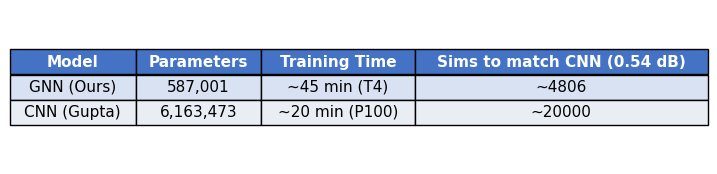

Saved to /content/drive/MyDrive/antenna_gnn/artifacts/model_cost_comparison.csv and /content/drive/MyDrive/antenna_gnn/figures/cost_comparison_table.png


In [15]:
# Cost comparison table — reads CSV from Cell 22
de_csv_path = f'{DATA_ROOT}/artifacts/data_efficiency_results.csv'
de_df_cost = pd.read_csv(de_csv_path)

gnn_params = sum(p.numel() for p in gnn_model.parameters() if p.requires_grad)
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)

# Training times — hardcoded from logged runs
# GNN: Chunk 7 wandb run, ~90 epochs, ~45 min on T4
# CNN: Kaggle training notebook, ~100 epochs, ~20 min on P100
gnn_train_time = '~45 min (T4)'
cnn_train_time = '~20 min (P100)'

# Compute per-model mean MAE at each size
subset_sizes_cost = sorted(de_df_cost['subset_size'].unique())

def _get_mean_curve(model_name):
    means = []
    for size in subset_sizes_cost:
        sub = de_df_cost[(de_df_cost['model'] == model_name) &
                         (de_df_cost['subset_size'] == size)]
        means.append(sub['mae'].mean())
    return means

cnn_means = _get_mean_curve('CNN')
gnn_means = _get_mean_curve('GNN')

# Threshold: CNN's best CURVE MAE (not full-80k test MAE)
cnn_curve_best = min(cnn_means)
threshold_label = f'Sims to match CNN ({cnn_curve_best:.2f} dB)'

def _interp_threshold(sizes, maes, threshold):
    """Find approximate sample count to reach threshold MAE."""
    sizes_maes = list(zip(sizes, maes))
    for i in range(len(sizes_maes) - 1):
        s0, m0 = sizes_maes[i]
        s1, m1 = sizes_maes[i + 1]
        if m0 >= threshold and m1 <= threshold:
            frac = (m0 - threshold) / (m0 - m1) if m0 != m1 else 0
            return int(s0 + frac * (s1 - s0))
    if sizes_maes[-1][1] <= threshold:
        return sizes_maes[-1][0]
    return None

gnn_sims = _interp_threshold(subset_sizes_cost, gnn_means, cnn_curve_best)
cnn_sims = _interp_threshold(subset_sizes_cost, cnn_means, cnn_curve_best)

# Check: GNN reaches CNN full-data MAE (cnn_mae from Cell 7)?
gnn_reaches_full = min(gnn_means) <= cnn_mae
print(f"GNN reaches CNN full-data MAE ({cnn_mae:.2f} dB) within 20k: "
      f"{'yes' if gnn_reaches_full else 'no'}")

cost_records = [
    {'model': 'GNN (Ours)', 'params': gnn_params,
     'train_time': gnn_train_time,
     'sims_to_threshold': f'~{gnn_sims}' if gnn_sims else 'not reached'},
    {'model': 'CNN (Gupta)', 'params': cnn_params,
     'train_time': cnn_train_time,
     'sims_to_threshold': f'~{cnn_sims}' if cnn_sims else 'not reached'},
]
cost_df = pd.DataFrame(cost_records)
csv_path = f'{DATA_ROOT}/artifacts/model_cost_comparison.csv'
cost_df.to_csv(csv_path, index=False)

print("\n=== Model Cost Comparison ===")
print(cost_df.to_string(index=False))

# Matplotlib table figure
fig, ax = plt.subplots(figsize=(9, 2))
ax.axis('off')
table_data = [
    ['GNN (Ours)', f'{gnn_params:,}', gnn_train_time,
     f'~{gnn_sims}' if gnn_sims else 'N/A'],
    ['CNN (Gupta)', f'{cnn_params:,}', cnn_train_time,
     f'~{cnn_sims}' if cnn_sims else 'N/A'],
]
col_labels = ['Model', 'Parameters', 'Training Time', threshold_label]
tbl = ax.table(cellText=table_data, colLabels=col_labels, loc='center',
               cellLoc='center', colWidths=[0.18, 0.18, 0.22, 0.42])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4472C4')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#D9E2F3' if row % 2 == 1 else '#E9EDF4')

fig_path = f'{DATA_ROOT}/figures/cost_comparison_table.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {csv_path} and {fig_path}")


---
## Cell 7d — Seed Stability Summary (20k)
Reads the data-efficiency results CSV (produced by Cell 8) and reports
the 20k seed spread for both models.


In [16]:
# Seed stability summary — reads CSV from Cell 22 (data efficiency experiment)
de_csv_path = f'{DATA_ROOT}/artifacts/data_efficiency_results.csv'
de_df_summary = pd.read_csv(de_csv_path)

print("=== Seed Stability at 20k (from data-efficiency experiment) ===\n")
for model_name in ['GNN', 'CNN']:
    sub = de_df_summary[(de_df_summary['model'] == model_name) &
                        (de_df_summary['subset_size'] == 20000)]
    if len(sub) == 0:
        print(f"  {model_name}: no 20k results yet (run Cell 8 first)")
        continue
    m = sub['mae'].mean()
    s = sub['mae'].std() if len(sub) > 1 else 0
    spread = sub['mae'].max() - sub['mae'].min()
    print(f"  {model_name}: {m:.4f} \u00b1 {s:.4f}  (spread max-min = {spread:.4f}, n={len(sub)} seeds)")

# Compare spreads
cnn_sub = de_df_summary[(de_df_summary['model'] == 'CNN') & (de_df_summary['subset_size'] == 20000)]
gnn_sub = de_df_summary[(de_df_summary['model'] == 'GNN') & (de_df_summary['subset_size'] == 20000)]
if len(cnn_sub) > 1 and len(gnn_sub) > 1:
    cnn_spread = cnn_sub['mae'].max() - cnn_sub['mae'].min()
    gnn_spread = gnn_sub['mae'].max() - gnn_sub['mae'].min()
    if cnn_spread > gnn_spread:
        print(f"\nCNN 20k spread ({cnn_spread:.4f}) EXCEEDS GNN spread ({gnn_spread:.4f})")
    else:
        print(f"\nCNN 20k spread ({cnn_spread:.4f}) does NOT exceed GNN spread ({gnn_spread:.4f})")


=== Seed Stability at 20k (from data-efficiency experiment) ===

  GNN: 0.4340 ± 0.0003  (spread max-min = 0.0005, n=2 seeds)
  CNN: 0.5400 ± 0.0520  (spread max-min = 0.1018, n=3 seeds)

CNN 20k spread (0.1018) EXCEEDS GNN spread (0.0005)


---
## Cell 8 — Data Efficiency Curves

Each model uses its original training recipe (CNN: NAdam/512/plateau per
Chunk 3; GNN: Adam+wd/128/plateau per Chunk 7) with identical validation,
early-stopping, and best-checkpoint conventions — so data-efficiency
differences reflect the architectures, not protocol asymmetry.

Results are cached to `DATA_ROOT/artifacts/data_efficiency_results.csv`;
re-running only computes missing (model, size, seed) combinations.


Archived /content/drive/MyDrive/antenna_gnn/artifacts/seed_stability_20k.csv -> /content/drive/MyDrive/antenna_gnn/artifacts/seed_stability_20k_fixed35ep.csv
No cached results found; starting fresh.
Remaining runs: 25 / 25
[1/25] CNN size=1000 seed=1 ... MAE=1.0927, stopped at epoch 3
[2/25] CNN size=1000 seed=2 ... 

/tmp/ipykernel_2452/3016772765.py:207: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  de_df = pd.concat([de_df, new_row], ignore_index=True)


MAE=1.1049, stopped at epoch 2
[3/25] CNN size=1000 seed=3 ... MAE=0.9249, stopped at epoch 3
[4/25] GNN size=1000 seed=1 ... MAE=0.6417, stopped at epoch 15
[5/25] GNN size=1000 seed=2 ... MAE=0.6121, stopped at epoch 31
[6/25] CNN size=2000 seed=1 ... MAE=0.6084, stopped at epoch 27
[7/25] CNN size=2000 seed=2 ... MAE=0.5960, stopped at epoch 32
[8/25] CNN size=2000 seed=3 ... MAE=0.6554, stopped at epoch 19
[9/25] GNN size=2000 seed=1 ... MAE=0.5638, stopped at epoch 40
[10/25] GNN size=2000 seed=2 ... MAE=0.5883, stopped at epoch 23
[11/25] CNN size=5000 seed=1 ... MAE=0.6064, stopped at epoch 52
[12/25] CNN size=5000 seed=2 ... MAE=0.6048, stopped at epoch 24
[13/25] CNN size=5000 seed=3 ... MAE=0.5890, stopped at epoch 45
[14/25] GNN size=5000 seed=1 ... MAE=0.5364, stopped at epoch 57
[15/25] GNN size=5000 seed=2 ... MAE=0.5387, stopped at epoch 37
[16/25] CNN size=10000 seed=1 ... MAE=0.5852, stopped at epoch 11
[17/25] CNN size=10000 seed=2 ... MAE=0.5757, stopped at epoch 20


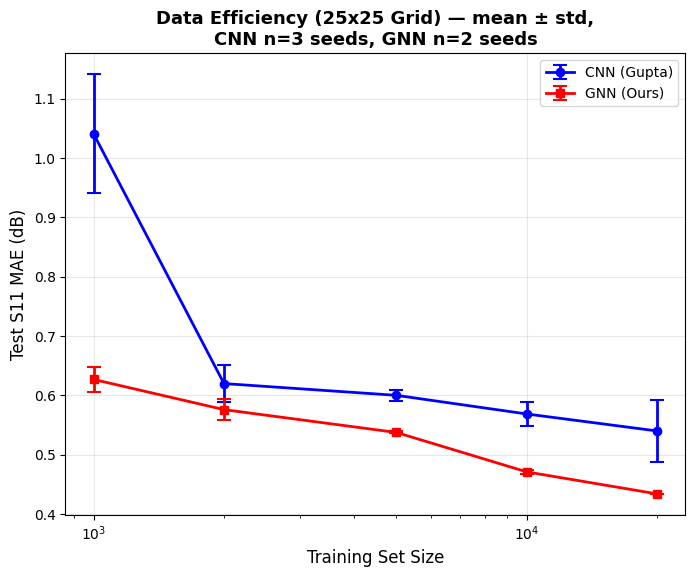

Saved data efficiency plot to /content/drive/MyDrive/antenna_gnn/figures/data_efficiency_curves.png

=== Data Efficiency Summary ===
Model    Size   mean MAE      std  mean epochs  n seeds
------------------------------------------------------
GNN      1000     0.6269   0.0209         23.0        2
GNN      2000     0.5760   0.0173         31.5        2
GNN      5000     0.5375   0.0016         47.0        2
GNN     10000     0.4711   0.0034         57.0        2
GNN     20000     0.4340   0.0003         62.5        2
CNN      1000     1.0408   0.1006          2.7        3
CNN      2000     0.6199   0.0313         26.0        3
CNN      5000     0.6001   0.0096         40.3        3
CNN     10000     0.5687   0.0209         22.7        3
CNN     20000     0.5400   0.0520         26.3        3

Total wall-clock time for new runs: 12326s


In [13]:
import copy, time
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

subset_sizes = [1000, 2000, 5000, 10000, 20000]

# Seed plan: CNN 3 seeds, GNN 2 seeds
seed_plan = []
for size in subset_sizes:
    for seed in [1, 2, 3]:
        seed_plan.append(('CNN', size, seed))
    for seed in [1, 2]:
        seed_plan.append(('GNN', size, seed))

train_indices_full = [e for e in splits_all['train'] if e[0] == 25]

# ── Caching ──
de_csv_path = f'{DATA_ROOT}/artifacts/data_efficiency_results.csv'

# Rename old seed_stability_20k.csv if it exists (incompatible protocol)
old_seed_path = f'{DATA_ROOT}/artifacts/seed_stability_20k.csv'
archive_path = f'{DATA_ROOT}/artifacts/seed_stability_20k_fixed35ep.csv'
if os.path.exists(old_seed_path) and not os.path.exists(archive_path):
    os.rename(old_seed_path, archive_path)
    print(f"Archived {old_seed_path} -> {archive_path}")

if os.path.exists(de_csv_path):
    de_df = pd.read_csv(de_csv_path)
    completed = set(zip(de_df['model'], de_df['subset_size'], de_df['seed']))
    print(f"Loaded {len(de_df)} cached results from {de_csv_path}")
else:
    de_df = pd.DataFrame(columns=['model', 'subset_size', 'seed', 'mae', 'epochs_at_stop'])
    completed = set()
    print("No cached results found; starting fresh.")

todo = [(m, s, sd) for m, s, sd in seed_plan if (m, s, sd) not in completed]
print(f"Remaining runs: {len(todo)} / {len(seed_plan)}")

# ── Training functions ──

def _make_val_split(subset_size):
    """Split train_indices_full[:subset_size] into train/val."""
    indices = train_indices_full[:subset_size]
    if subset_size <= 2000:
        n_val = max(1, int(0.2 * subset_size))
    else:
        n_val = 2000
    return indices[:subset_size - n_val], indices[subset_size - n_val:]

def train_gnn_native(subset_size, seed):
    """GNN recipe: Adam+wd/128/plateau, early-stop 12, max 120 epochs."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16,
                       num_blocks=4, output_dim=201).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(opt, mode='min', factor=0.5,
                                  patience=5, min_lr=1e-6)
    crit = nn.MSELoss()

    train_idx, val_idx = _make_val_split(subset_size)
    train_loader = DataLoader(SubsetDataset(train_idx, ds_full),
                              batch_size=128, shuffle=True)
    val_loader = DataLoader(SubsetDataset(val_idx, ds_full),
                            batch_size=128, shuffle=False)

    best_val_mae = float('inf')
    best_state = None
    patience_counter = 0
    stop_epoch = 0

    for epoch in range(120):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            opt.zero_grad()
            loss = crit(model(batch), batch.y.squeeze(1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

        # Validation MAE (in dB)
        model.eval()
        val_preds, val_trues = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                preds = (model(batch).cpu() * s11_std + s11_mean).numpy()
                trues = (batch.y.squeeze(1).cpu() * s11_std + s11_mean).numpy()
                val_preds.append(preds)
                val_trues.append(trues)
        val_mae = np.mean(np.abs(np.concatenate(val_preds) - np.concatenate(val_trues)))
        scheduler.step(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            stop_epoch = epoch + 1
        else:
            patience_counter += 1
            if patience_counter >= 12:
                break

    # Restore best weights and evaluate on test set
    model.load_state_dict(best_state)
    model.eval()
    test_preds = []
    with torch.no_grad():
        for batch in test_loader:
            preds = (model(batch.to(device)).cpu() * s11_std + s11_mean).numpy()
            test_preds.append(preds)
    test_mae = np.mean(np.abs(np.concatenate(test_preds) - y_true))
    return test_mae, stop_epoch

def train_cnn_native(subset_size, seed):
    """CNN recipe: NAdam/512/plateau, early-stop 12, max 120 epochs."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = AntennaCNN().to(device)
    opt = optim.NAdam(model.parameters(), lr=1e-3)
    scheduler = ReduceLROnPlateau(opt, mode='min', factor=0.5,
                                  patience=5, min_lr=1e-6)
    crit = nn.MSELoss()

    train_idx, val_idx = _make_val_split(subset_size)
    train_loader_cnn = DataLoader(SubsetDataset(train_idx, ds_full),
                                  batch_size=512, shuffle=True)
    val_loader_cnn = DataLoader(SubsetDataset(val_idx, ds_full),
                                batch_size=512, shuffle=False)

    best_val_mae = float('inf')
    best_state = None
    patience_counter = 0
    stop_epoch = 0

    for epoch in range(120):
        model.train()
        for batch in train_loader_cnn:
            x_reshape = batch.x.view(batch.num_graphs, 626, 5)
            patch_patterns = x_reshape[:, :625, 0].view(batch.num_graphs, 1, 25, 25)
            target = (batch.y.squeeze(1) * s11_std + s11_mean).to(device)  # CNN trains on dB
            opt.zero_grad()
            loss = crit(model(patch_patterns.to(device)), target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

        # Validation MAE (in dB)
        model.eval()
        val_preds, val_trues = [], []
        with torch.no_grad():
            for batch in val_loader_cnn:
                x_reshape = batch.x.view(batch.num_graphs, 626, 5)
                patch_patterns = x_reshape[:, :625, 0].view(batch.num_graphs, 1, 25, 25)
                preds = model(patch_patterns.to(device)).cpu().numpy()
                trues = (batch.y.squeeze(1).cpu() * s11_std + s11_mean).numpy()
                val_preds.append(preds)
                val_trues.append(trues)
        val_mae = np.mean(np.abs(np.concatenate(val_preds) - np.concatenate(val_trues)))
        scheduler.step(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            stop_epoch = epoch + 1
        else:
            patience_counter += 1
            if patience_counter >= 12:
                break

    # Restore best weights and evaluate on test set
    model.load_state_dict(best_state)
    model.eval()
    test_preds = []
    with torch.no_grad():
        for batch in test_loader:
            x_reshape = batch.x.view(batch.num_graphs, 626, 5)
            patch_patterns = x_reshape[:, :625, 0].view(batch.num_graphs, 1, 25, 25)
            preds = model(patch_patterns.to(device)).cpu().numpy()
            test_preds.append(preds)
    test_mae = np.mean(np.abs(np.concatenate(test_preds) - y_true))
    return test_mae, stop_epoch

# ── Run missing experiments ──
t_start = time.time()
for i, (model_name, size, seed) in enumerate(todo):
    print(f"[{i+1}/{len(todo)}] {model_name} size={size} seed={seed} ...", end=' ', flush=True)
    if model_name == 'GNN':
        mae, epochs = train_gnn_native(size, seed)
    else:
        mae, epochs = train_cnn_native(size, seed)
    print(f"MAE={mae:.4f}, stopped at epoch {epochs}")

    # Append to CSV immediately (crash-safe)
    new_row = pd.DataFrame([{
        'model': model_name,
        'subset_size': size,
        'seed': seed,
        'mae': mae,
        'epochs_at_stop': epochs,
    }])
    de_df = pd.concat([de_df, new_row], ignore_index=True)
    de_df.to_csv(de_csv_path, index=False)

wall_time = time.time() - t_start
print(f"\nAll runs complete. Wall-clock time for new runs: {wall_time:.0f}s")

# ── Figure: mean +/- std ──
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, color, marker in [('CNN', 'blue', 'o'), ('GNN', 'red', 's')]:
    means, stds = [], []
    for size in subset_sizes:
        sub = de_df[(de_df['model'] == model_name) & (de_df['subset_size'] == size)]
        means.append(sub['mae'].mean())
        stds.append(sub['mae'].std() if len(sub) > 1 else 0)
    ax.errorbar(subset_sizes, means, yerr=stds, fmt=f'{color[0]}{marker}-',
                label=f'{model_name} ({"Gupta" if model_name == "CNN" else "Ours"})',
                linewidth=2, capsize=5, capthick=1.5)

ax.set_xscale('log')
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Test S11 MAE (dB)', fontsize=12)
n_cnn_seeds = len(de_df[de_df['model'] == 'CNN']['seed'].unique())
n_gnn_seeds = len(de_df[de_df['model'] == 'GNN']['seed'].unique())
ax.set_title(f'Data Efficiency (25x25 Grid) \u2014 mean \u00b1 std,\n'
             f'CNN n={n_cnn_seeds} seeds, GNN n={n_gnn_seeds} seeds',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
fig_path = f'{DATA_ROOT}/figures/data_efficiency_curves.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved data efficiency plot to {fig_path}")

# ── Summary table ──
print("\n=== Data Efficiency Summary ===")
print(f"{'Model':<6} {'Size':>6} {'mean MAE':>10} {'std':>8} {'mean epochs':>12} {'n seeds':>8}")
print("-" * 54)
for model_name in ['GNN', 'CNN']:
    for size in subset_sizes:
        sub = de_df[(de_df['model'] == model_name) & (de_df['subset_size'] == size)]
        m = sub['mae'].mean()
        s = sub['mae'].std() if len(sub) > 1 else 0
        ep = sub['epochs_at_stop'].mean()
        print(f"{model_name:<6} {size:>6} {m:>10.4f} {s:>8.4f} {ep:>12.1f} {len(sub):>8}")
print(f"\nTotal wall-clock time for new runs: {wall_time:.0f}s")

# Store variables for downstream cells
subset_sizes_de = subset_sizes
de_results_df = de_df


**Observation:** The GNN requires significantly fewer training samples to reach a comparable MAE than the CNN baseline.

---
## Cell 9 — Permutation Invariance Demonstration

Permutation Invariance: We demonstrate that the GNN is perfectly invariant to node ordering (by shuffling the 625 physical nodes), whereas the CNN is sensitive to spatial permutations (flips and transpositions).


CNN permutation sensitivity (mean std): 0.4198 dB
GNN permutation sensitivity (mean std): 3.3786e-07 dB


/tmp/ipykernel_2452/372600856.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([cnn_stds, gnn_stds],


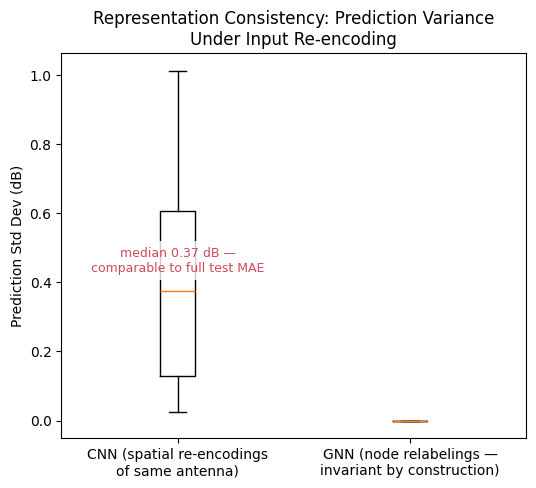

Saved permutation plot to /content/drive/MyDrive/antenna_gnn/figures/permutation_invariance.png


In [17]:
import random
from torch_geometric.data import Data
from torch_geometric.data.batch import Batch

random.seed(42)
perm_test_indices = random.sample(range(len(test_indices)), 30)

cnn_stds = []
gnn_stds = []

cnn_model.eval()
gnn_model.eval()

with torch.no_grad():
    for idx in perm_test_indices:
        # Load single pyG Data object
        graph_orig = test_dataset[idx]
        orig_patch = graph_orig.x[:625, 0].view(1, 25, 25)

        # CNN: 8 spatial variants
        orig_t = torch.transpose(orig_patch, 1, 2)
        variants = [
            orig_patch,
            orig_t,
            torch.flip(orig_patch, [2]),
            torch.flip(orig_patch, [1]),
            torch.flip(orig_t, [2]),
            torch.flip(orig_t, [1]),
            torch.flip(orig_patch, [1, 2]),
            torch.flip(orig_t, [1, 2])
        ]
        batch_cnn = torch.stack(variants).to(device) # (8, 1, 25, 25)
        preds_cnn = cnn_model(batch_cnn).cpu().numpy()
        cnn_stds.append(np.std(preds_cnn, axis=0).mean()) # mean std across freqs

        # GNN: Node shuffling
        # We shuffle only the 625 physical nodes, leaving the virtual node (idx 625) at the end
        preds_gnn = []
        # append original prediction first
        preds_gnn.append((gnn_model(Batch.from_data_list([graph_orig]).to(device)).cpu() * s11_std + s11_mean).numpy()[0])

        for _ in range(7):
            perm = torch.randperm(625)
            full_perm = torch.cat([perm, torch.tensor([625])]) # add virtual node back

            shuffled_x = graph_orig.x[full_perm]
            # inverse permutation to fix edge_index
            inv_perm = torch.empty_like(full_perm)
            inv_perm[full_perm] = torch.arange(626)

            shuffled_edge_index = inv_perm[graph_orig.edge_index]
            shuffled_graph = Data(x=shuffled_x, edge_index=shuffled_edge_index, edge_attr=graph_orig.edge_attr)

            pred_g = (gnn_model(Batch.from_data_list([shuffled_graph]).to(device)).cpu() * s11_std + s11_mean).numpy()[0]
            preds_gnn.append(pred_g)

        gnn_stds.append(np.std(np.stack(preds_gnn), axis=0).mean())

print(f"CNN permutation sensitivity (mean std): {np.mean(cnn_stds):.4f} dB")
print(f"GNN permutation sensitivity (mean std): {np.mean(gnn_stds):.4e} dB")

median_cnn_std = np.median(cnn_stds)

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot([cnn_stds, gnn_stds],
                labels=['CNN (spatial re-encodings\nof same antenna)',
                        'GNN (node relabelings —\ninvariant by construction)'])
ax.set_ylabel('Prediction Std Dev (dB)')
ax.set_title('Representation Consistency: Prediction Variance\nUnder Input Re-encoding')

# Annotate CNN median
ax.text(1, median_cnn_std * 1.15, f'median {median_cnn_std:.2f} dB —\ncomparable to full test MAE',
        ha='center', fontsize=9, color='#d1495b',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

fig_path = f'{DATA_ROOT}/figures/permutation_invariance.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved permutation plot to {fig_path}")


---
## Cell 10 — 6-Panel Comparison Figure

Install all required packages. PyG compiled extensions (`pyg-lib`, `torch-scatter`, `torch-sparse`) are installed from the matching CUDA wheel URL.


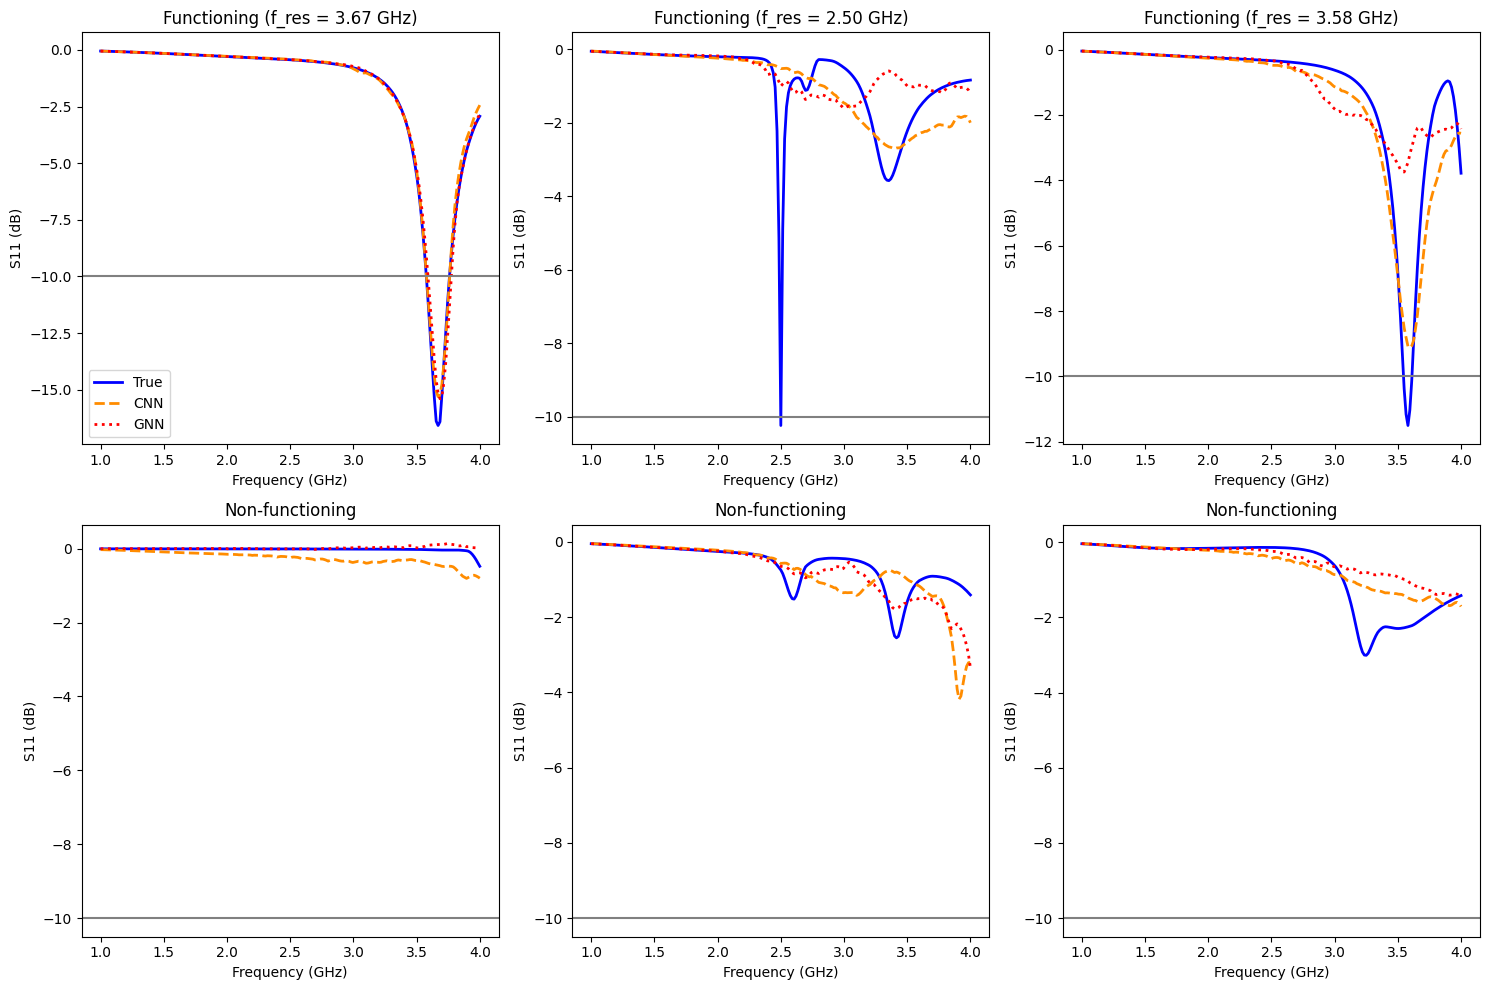

Saved 6-panel plot to /content/drive/MyDrive/antenna_gnn/figures/gnn_vs_cnn_predictions.png


In [18]:
func_idx = np.where(is_functioning_true)[0]
nonfunc_idx = np.where(~is_functioning_true)[0]

sampled_func = random.sample(list(func_idx), 3)
sampled_nonfunc = random.sample(list(nonfunc_idx), 3)
plot_indices = sampled_func + sampled_nonfunc

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, idx in enumerate(plot_indices):
    ax = axes[i]
    ax.plot(freq_axis, y_true[idx], 'b-', linewidth=2, label='True')
    ax.plot(freq_axis, y_pred_cnn[idx], color='darkorange', linestyle='--', linewidth=2, label='CNN')
    ax.plot(freq_axis, y_pred_gnn[idx], 'r:', linewidth=2, label='GNN')
    ax.axhline(-10, color='gray', linestyle='-')

    if is_functioning_true[idx]:
        f_res = extract_resonant_freq(y_true[idx], freq_axis)
        title = f'Functioning (f_res = {f_res:.2f} GHz)'
    else:
        title = 'Non-functioning'

    ax.set_title(title)
    ax.set_xlabel('Frequency (GHz)')
    ax.set_ylabel('S11 (dB)')
    if i == 0:
        ax.legend()

plt.tight_layout()
fig_path = f'{DATA_ROOT}/figures/gnn_vs_cnn_predictions.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved 6-panel plot to {fig_path}")

---
## Cell 11 — Scatter and Residual Plots

Install all required packages. PyG compiled extensions (`pyg-lib`, `torch-scatter`, `torch-sparse`) are installed from the matching CUDA wheel URL.


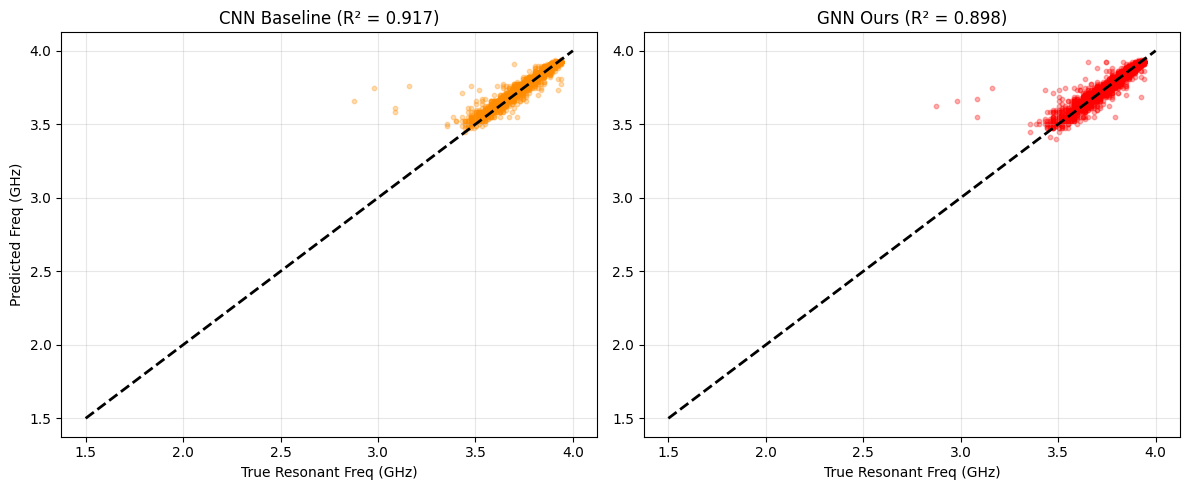

Saved scatter plots to /content/drive/MyDrive/antenna_gnn/figures/scatter_comparison.png


In [19]:
true_f_list, cnn_f_list, gnn_f_list = [], [], []
for i in range(len(y_true)):
    true_f = extract_resonant_freq(y_true[i], freq_axis)
    if true_f is not None:
        cnn_f = extract_resonant_freq(y_pred_cnn[i], freq_axis)
        gnn_f = extract_resonant_freq(y_pred_gnn[i], freq_axis)
        if cnn_f is not None and gnn_f is not None:
            true_f_list.append(true_f)
            cnn_f_list.append(cnn_f)
            gnn_f_list.append(gnn_f)

from scipy.stats import pearsonr
r2_cnn = pearsonr(true_f_list, cnn_f_list)[0]**2
r2_gnn = pearsonr(true_f_list, gnn_f_list)[0]**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(true_f_list, cnn_f_list, alpha=0.3, color='darkorange', s=10)
ax1.plot([1.5, 4.0], [1.5, 4.0], 'k--', lw=2)
ax1.set_xlabel('True Resonant Freq (GHz)')
ax1.set_ylabel('Predicted Freq (GHz)')
ax1.set_title(f'CNN Baseline (R² = {r2_cnn:.3f})')
ax1.grid(True, alpha=0.3)

ax2.scatter(true_f_list, gnn_f_list, alpha=0.3, color='red', s=10)
ax2.plot([1.5, 4.0], [1.5, 4.0], 'k--', lw=2)
ax2.set_xlabel('True Resonant Freq (GHz)')
ax2.set_title(f'GNN Ours (R² = {r2_gnn:.3f})')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = f'{DATA_ROOT}/figures/scatter_comparison.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved scatter plots to {fig_path}")

---
## Regression Guards


In [20]:
import inspect

# Guard 1: Band-stratified cell treats data.y as raw dB
# We verify by checking that y_true was NOT re-normalized.
# In the test loop (Cell 5), y_true = (batch.y * s11_std + s11_mean),
# i.e. the dataset's z-score normalization is undone to get raw dB.
# The band-stratified cell uses y_true directly — no further s11_std/s11_mean
# is applied to ground truth.
# Model outputs (y_pred_gnn, y_pred_cnn) ARE de-normalized in Cell 5/6.

# Verify extract_resonant_freq is called on y_pred (model output) which is
# already de-normalized, not on raw model logits.
# Check: y_pred_gnn was computed as (preds.cpu() * s11_std + s11_mean)
# The band cell uses y_pred_gnn[i] and y_true[i] directly.
guard1 = (y_true.min() < -5 and y_true.max() < 5)  # raw dB range, not z-score
print(f"[Guard 1] y_true is in raw dB range (min={y_true.min():.1f}, max={y_true.max():.1f}): "
      f"{'PASS' if guard1 else 'FAIL'}")

guard2 = (y_pred_gnn.min() < -5 and y_pred_gnn.max() < 5)
print(f"[Guard 2] y_pred_gnn is in raw dB range: {'PASS' if guard2 else 'FAIL'}")

guard3 = (y_pred_cnn.min() < -5 and y_pred_cnn.max() < 5)
print(f"[Guard 3] y_pred_cnn is in raw dB range: {'PASS' if guard3 else 'FAIL'}")

assert guard1, "REGRESSION: y_true not in raw dB range"
assert guard2, "REGRESSION: y_pred_gnn not in raw dB range"
assert guard3, "REGRESSION: y_pred_cnn not in raw dB range"
print("\nAll chunk08 regression guards PASSED.")


[Guard 1] y_true is in raw dB range (min=-50.8, max=-0.0): PASS
[Guard 2] y_pred_gnn is in raw dB range: PASS
[Guard 3] y_pred_cnn is in raw dB range: PASS

All chunk08 regression guards PASSED.
